In [1]:
from ase.io.trajectory import Trajectory
import chemcoord as cc

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

/home/anacristina/.local/lib/python3.6/site-packages/numba/core/errors.py:154: UserWarning: Insufficiently recent colorama version found. Numba requires colorama >= 0.3.9
  warnings.warn(msg)


In [2]:
def database_xyz(is_xyz, energies_is, Natoms):
    
    cols = np.array([['x'+str(i), 'y'+str(i), 'z'+str(i)] for i in range(Natoms)]).reshape(1, -1)[0]
    cols = np.append(cols, 'energy')
    
    save_is_xyz = pd.DataFrame(columns=cols, index=np.arange(0, len(is_xyz), 1))
    
    for i in range(len(is_xyz)):
        save_is_xyz.iloc[i] = is_xyz[i].iloc[:, 1:].to_numpy().flatten().tolist()+[energies_is[i]]
    
    return save_is_xyz

In [3]:
def database_zmat(is_zmat, energies_is, construction_table_):
    b = construction_table_.b.to_numpy()
    a = construction_table_.a.to_numpy()
    d = construction_table_.d.to_numpy()
    ind = construction_table_.index.to_numpy()

    label_b = ['bond'+str(i)+str(j) for i, j in zip(ind, b)]
    label_a = ['angle'+str(i)+str(j) for i, j in zip(ind, a)]
    label_d = ['dihedral'+str(i)+str(j) for i, j in zip(ind, d)]

    cols = label_b + label_a + label_d + ['energies']
    
    save_is_zmat = pd.DataFrame(columns = cols, index=np.arange(0, len(is_zmat), 1))
    
    for i in range(len(is_zmat)):
        save_is_zmat.iloc[i] = is_zmat[i].iloc[:, 2].tolist()+is_zmat[i].iloc[:, 4].tolist()+is_zmat[i].iloc[:, 6].tolist()+[energies_is[i]]
    
    return save_is_zmat

In [4]:
def get_df_xyz_zmat(file_name, construction_table):
    traj = Trajectory(file_name)[:1950]
    Nats = traj[0].get_global_number_of_atoms()
    xyz = np.array([cc.Cartesian.from_ase_atoms(traj_) for traj_ in traj])
    energies = [traj_.get_potential_energy() for traj_ in traj]
    
    zmat = [xyz_.get_zmat(construction_table) for xyz_ in xyz]
    
    pd_is_xyz = database_xyz(xyz, energies, Nats)
    pd_is_zmat = database_zmat(zmat, energies, construction_table)
    
    return pd_is_xyz, pd_is_zmat

In [5]:
def rephase(pd_is_zmat, angle, columns):
    for column in columns:
        phase_is = np.zeros(pd_is_zmat[column].shape)
        phase_is[pd_is_zmat[column]>angle] = -360
        pd_is_zmat[column] = pd_is_zmat[column] + phase_is
    return pd_is_zmat

In [6]:
def deg_to_rad(pd_is_fd_zmat):
    labels = pd_is_fd_zmat.columns.to_list()
    for label in labels[6:-1]:
        pd_is_fd_zmat[label] = np.deg2rad(pd_is_fd_zmat[label].tolist())
    return pd_is_fd_zmat

In [7]:
def plot_pd_zmat(pd_is_zmat):
    labels = pd_is_zmat.keys().tolist()
    data1 = pd_is_zmat.to_numpy()
    plt.figure(figsize=(6, 4))
    plt.plot(labels, data1.T, '.');
    plt.xticks(rotation = 90);

In [8]:
def write_xyz_zmat(df_xyz, df_zmat, name_csv):
    df_xyz.to_csv(name_csv+'_xyz.csv', index=False)
    df_zmat.to_csv(name_csv+'_zmat.csv', index=False)

In [9]:
index_1 = np.append(0, np.append(np.arange(2,6), 1))
construction_table_is1 = pd.DataFrame(index=index_1)

construction_table_is1['b'] = ['origin', 0, 2, 2, 4, 4]
construction_table_is1['a'] = ['e_z', 'e_z', 0, 3, 2, 2]
construction_table_is1['d'] = ['e_x', 'e_x', 'e_x', 0, 3, 3]

index_2 = np.append(3, np.append(np.arange(0,3), [4, 5]))
construction_table_is2 = pd.DataFrame(index=index_2)

construction_table_is2['b'] = ['origin', 3, 0, 0, 1, 4]
construction_table_is2['a'] = ['e_z', 'e_z', 3, 1, 0, 1]
construction_table_is2['d'] = ['e_x', 'e_x', 'e_x', 3, 2, 0]

In [10]:
mode = "lcao"

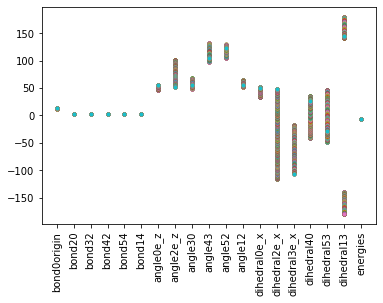

In [11]:
pd_is1_fd_xyz, pd_is1_fd_zmat = get_df_xyz_zmat('ag6_is1_'+mode+'.traj', construction_table_is1)
plot_pd_zmat(pd_is1_fd_zmat)

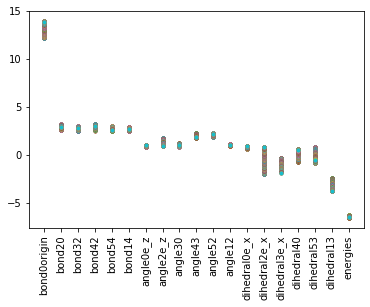

In [12]:
pd_is1_fd_zmat = rephase(pd_is1_fd_zmat, 0, ['dihedral13'])
pd_is1_fd_zmat = deg_to_rad(pd_is1_fd_zmat)
plot_pd_zmat(pd_is1_fd_zmat)

In [13]:
write_xyz_zmat(pd_is1_fd_xyz, pd_is1_fd_zmat, 'is1_'+mode+'')

In [ ]:
pd_is2_fd_xyz, pd_is2_fd_zmat = get_df_xyz_zmat('ag6_is2_'+mode+'.traj', construction_table_is2)
plot_pd_zmat(pd_is2_fd_zmat)

In [ ]:
pd_is2_fd_zmat = rephase(pd_is2_fd_zmat, 0, ['dihedral1e_x'])
pd_is2_fd_zmat = deg_to_rad(pd_is2_fd_zmat)
plot_pd_zmat(pd_is2_fd_zmat)

In [ ]:
write_xyz_zmat(pd_is2_fd_xyz, pd_is2_fd_zmat, 'is2_'+mode+'')